**Feature Engineering**

Feature Engineering is the process of transforming raw data into meaningful features (input variables) that improve the performance of Machine Learning models. It is one of the most important stages in the Data Science lifecycle because even the most advanced algorithm cannot perform well if the input data is poor.


**Missing Values & Handling Missing Values in Feature Engineering**

What is a Missing Value?

A missing value represents unavailable information.

Common representations:

*   None
*   NULL
*   NA
*   N/A
*   NaN
*   ''
*   ?

**There are three main types of missing data:**

**Missing completely at random (MCAR)**  - Missing data are randomly distributed across the variable and unrelated to other variables.

**Missing at random (MAR)** - Missing data are not randomly distributed but they are accounted for by other observed variables.

**Missing not at random (MNAR)** - Missing data systematically differ from the observed values.

















In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**1. Detect Missing Values**

`isnull()` : Returns True for missing values and False otherwise

`isna() `: Same as isnull().

**Checking Missing values in a dataset**

In [4]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


**Count Missing Values**

Column-wise Missing Values : `df.isnull().sum()`

Percentage of Missing Values : `(df.isnull().sum()/len(df))*100`

In [5]:
# The sum() function is crucial here because df.isnull() returns a DataFrame
# of boolean values (True where a value is missing, False otherwise). When you
# apply sum() to a boolean Series or DataFrame in Pandas, it treats True as 1
# and False as 0. Therefore, df.isnull().sum() calculates the sum of 1s
# (True values) for each column, effectively counting the total number of
# missing entries in each respective column.

df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


<Axes: >

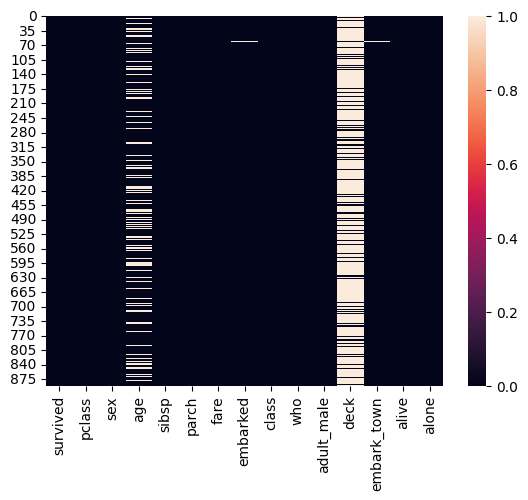

In [10]:
sns.heatmap(df.isnull())

**Handling missing values by deleting rows**


In [11]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
df.shape

(891, 15)

**Remove Missing Values**

`dropna()` : Removes rows containing missing values.



In [12]:
# Drop Row - which have missing values
df.dropna()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [15]:
# Most of the rows are deleted (Not a Good Approach) previously rows are 891
df.dropna().shape

(182, 15)

In [16]:
# Handling missing values by deleting columns
df.dropna(axis=1)

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


# **Imputation Techniques**


**Mean Imputation**: Fill with the average. (Best for symmetric, normally distributed numerical data with no extreme outliers).

**Median Imputation**: Fill with the middle value. (Industry Favorite for skewed numerical data, like income or real estate prices, because it ignores outliers).

**Mode Imputation**: Fill with the most frequent label. (The standard rule for categorical/text columns).

/tmp/ipykernel_1797/3234920688.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'])


<Axes: xlabel='age', ylabel='Density'>

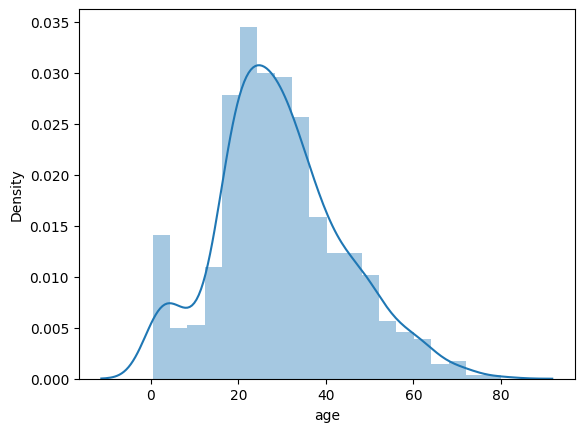

In [17]:
sns.distplot(df['age'])

In [18]:
df.age.isnull().sum()

np.int64(177)

In [20]:
df['Age_Mean'] = df['age'].fillna(df['age'].mean())

In [21]:
# This technique work well when your data is normally distributed
df[['Age_Mean','age']]

,Age_Mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


**2. Median Value Imputation**: If you an outlier in a dataset use this technique\

In [22]:
df['Age_Median'] = df['age'].fillna(df['age'].median())

In [23]:
df[['Age_Mean','age','Age_Median']]

,Age_Mean,age,Age_Median
0,22.000000,22.0,22.0
1,38.000000,38.0,38.0
2,26.000000,26.0,26.0
3,35.000000,35.0,35.0
4,35.000000,35.0,35.0
...,...,...,...
886,27.000000,27.0,27.0
887,19.000000,19.0,19.0
888,29.699118,NaN,28.0
889,26.000000,26.0,26.0


**3. Mode Value Imputation**

In [24]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_Mean,Age_Median
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,22.0,22.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,38.0,38.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,26.0,26.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,35.0,35.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,35.0,35.0


In [32]:
# It selects and displays only those rows where the 'embarked' column has
# missing values. This is achieved by first creating a boolean Series with
# df['embarked'].isnull(), which returns True for missing values and False
# otherwise. Then, this boolean Series is used to index the DataFrame,
# effectively showing only the rows corresponding to True values in the
# 'embarked' column (i.e., rows with missing 'embarked' data).

df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_Mean,Age_Median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [28]:
# Find all the unique, distinct values present in the 'embarked' column of
# your DataFrame df. It returns these unique values as a NumPy array. This
# is particularly useful for understanding the different categories or
# entries within a categorical column, including any missing values
# represented as NaN.

df['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [29]:
# Calculates the mode of the 'embarked' column in your DataFrame df.
# The .mode() method returns a Series containing the most frequently
# occurring value(s). By adding [0], you are specifically selecting the
# first most frequent value, in case there are multiple modes with the same
# highest frequency. This is often used for mode imputation to fill missing
# categorical values.

df['embarked'].mode()[0]

'S'

In [33]:
mode = df['embarked'].mode()[0]

**Fill Missing Values** :
`fillna()`

In [34]:
df['embarked_mode'] = df['embarked'].fillna(mode)

In [35]:
df[['embarked','embarked_mode']]

,embarked,embarked_mode
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [36]:
df['embarked_mode'].isnull().sum()

np.int64(0)

In [31]:
df[df['age'].notna()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_Mean,Age_Median
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,22.0,22.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,38.0,38.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,26.0,26.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,35.0,35.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,35.0,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False,39.0,39.0
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,27.0,27.0
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,19.0,19.0
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,26.0,26.0


### **Forward Fill (ffill())**

Forward Fill (ffill) is a method used to fill missing values by copying the last available valid value into the missing cells. In simple words, when a value is missing, it takes the previous non-missing value and fills the gap. This technique is especially useful in time-series data, where the latest known value is assumed to remain unchanged until a new value is recorded. For example, if the temperature on Monday is 25°C and Tuesday's value is missing, forward fill will replace Tuesday's missing value with 25°C.

In [6]:
df['Age_ffill'] = df['age'].ffill()
df[['age', 'Age_ffill']]

,age,Age_ffill
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0
...,...,...
886,27.0,27.0
887,19.0,19.0
888,NaN,19.0
889,26.0,26.0


# **Backward Fill (bfill())**

Backward Fill `(bfill)` is a method used to fill missing values by using the next available valid value. In simple words, when a value is missing, it looks ahead and copies the next non-missing value to fill the gap. This technique is useful when the future value can reasonably represent the missing observation. For example, if Monday's temperature is missing and Tuesday's temperature is 25°C, backward fill will replace Monday's missing value with 25°C. In Pandas, this can be done using the bfill() method.

In [7]:
df['Age_bfill'] = df['age'].bfill()
df[['age', 'Age_bfill']]

,age,Age_bfill
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0
...,...,...
886,27.0,27.0
887,19.0,19.0
888,NaN,26.0
889,26.0,26.0


### **Replace Missing Values with a Constant**

Replace Missing Values with a Constant is a technique where all missing values are replaced with a fixed value such as `0`, `-1`, "`Unknown`", or "`Not Available`". This method is useful when the missing value itself has meaning or when working with machine learning algorithms that cannot handle` NaN `values. For numerical data, values like `0` or `-1` are commonly used, while for categorical data, placeholders such as "`Unknown`" or "`Missing`" are often used. For example, if a customer's age is missing, you might replace it with `-1` to indicate that the age is unknown rather than estimating it. This approach is simple, fast, and helps preserve information about missingness without making assumptions about the actual value.

In [8]:
df['Age_replaced_with_0'] = df['age'].fillna(0)
df[['age', 'Age_replaced_with_0']]

,age,Age_replaced_with_0
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0
...,...,...
886,27.0,27.0
887,19.0,19.0
888,NaN,0.0
889,26.0,26.0


### Replace Missing Values using `df.replace(np.nan, value)`

While `fillna()` is specifically designed for `NaN` values, `replace()` offers a more general way to substitute specific values in a DataFrame. When used with `np.nan`, it can also replace missing values. This method is useful when you want to replace any occurrence of `np.nan` with a specified value (e.g., `0`) across a column or the entire DataFrame.

For example, `df['Age_replaced_nan'] = df['age'].replace(np.nan, 0)` will replace all `NaN` values in the 'age' column with `0`.

In [9]:
df['Age_replaced_nan'] = df['age'].replace(np.nan, 0)
df[['age', 'Age_replaced_nan']]

,age,Age_replaced_nan
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0
...,...,...
886,27.0,27.0
887,19.0,19.0
888,NaN,0.0
889,26.0,26.0


### **Multiple Replacements with `df.replace()`**

The `replace()` method is quite powerful and can handle multiple replacements simultaneously. You can pass a dictionary to `replace()` where keys are the values to be replaced and values are their corresponding replacements. This is particularly useful when you need to standardize or clean different types of entries in your data.

For instance, `df.replace({np.nan: 0, "Unknown": "Missing"})` would replace all `NaN` values with `0` and all occurrences of the string "Unknown" with "Missing".

In [10]:
df_multi_replaced = df.replace({
    np.nan: 0,
    "Unknown":"Missing"
})

# Display a subset of the DataFrame to show the effect of multiple replacements
# For simplicity, let's check a column that might contain 'Unknown' if it existed, and 'age' for NaN replacement.
# Since 'Unknown' might not be in our current 'titanic' df, let's focus on a column where NaN was replaced by 0.
# We will use the 'Age_replaced_nan' column as a reference for NaN replacement.
df_multi_replaced[['age', 'Age_replaced_nan']].head()


,age,Age_replaced_nan
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0


### **Interpolation**

Interpolation is a technique used to estimate missing values based on the values of other observed data points. Unlike simple `fillna()` with a constant or mean/median, interpolation attempts to infer the missing value by looking at the trend or relationship between adjacent data points. This can be particularly useful for time-series data or any ordered data where a smooth transition between values is expected.

There are several methods for interpolation, with the most common being:

*   **Linear Interpolation**: This is the default method in pandas. It draws a straight line between the two nearest non-missing values and estimates the missing value along that line.
*   **Polynomial Interpolation**: Fits a polynomial function to the surrounding data points.
*   **Spline Interpolation**: Similar to polynomial but uses piecewise polynomials to create a smoother curve.

For example, `df['Age_interpolated'] = df['age'].interpolate(method='linear')` will fill missing 'age' values by estimating them based on the ages of the preceding and succeeding non-missing entries.

In [11]:
df['Age_interpolated'] = df['age'].interpolate(method='linear')
df[['age', 'Age_interpolated']].tail(10)

,age,Age_interpolated
881,33.0,33.0
882,22.0,22.0
883,28.0,28.0
884,25.0,25.0
885,39.0,39.0
886,27.0,27.0
887,19.0,19.0
888,NaN,22.5
889,26.0,26.0
890,32.0,32.0


### **SimpleImputer (Scikit-Learn)**

`SimpleImputer` is a class from Scikit-Learn's `sklearn.impute` module that provides a basic strategy for imputing missing values. It's designed to be used as part of a preprocessing pipeline in machine learning workflows. Unlike pandas' `fillna()` which directly modifies a DataFrame, `SimpleImputer` is a transformer that you `fit` to your data and then `transform` it.

Key features and strategies:

*   **`strategy='mean'`**: Replaces missing values with the mean of the column. Suitable for numerical data without extreme outliers.
*   **`strategy='median'`**: Replaces missing values with the median of the column. Robust to outliers in numerical data.
*   **`strategy='most_frequent'`**: Replaces missing values with the most frequent value (mode) of the column. Ideal for categorical data or numerical data with a strong modal value.
*   **`strategy='constant'`**: Replaces missing values with a specified constant value. This is similar to `fillna(value)` in pandas.

This approach is beneficial for consistency and integration into machine learning pipelines, as the same imputation strategy can be applied to both training and test datasets after fitting on the training data.

In [14]:
from sklearn.impute import SimpleImputer

# Create a copy of the DataFrame to work with for imputation
df_imputed = df.copy()

# --- Impute 'age' column using 'mean' strategy ---
# Initialize the imputer with the 'mean' strategy
imputer_mean = SimpleImputer(strategy='mean')

# Fit the imputer on the 'age' column and transform it
df_imputed['Age_imputed_mean'] = imputer_mean.fit_transform(df_imputed[['age']]).ravel()

# --- Impute 'embarked' column using 'most_frequent' strategy ---
# Initialize the imputer with the 'most_frequent' strategy
imputer_mode = SimpleImputer(strategy='most_frequent')

# Fit the imputer on the 'embarked' column and transform it
df_imputed['Embarked_imputed_mode'] = imputer_mode.fit_transform(df_imputed[['embarked']]).ravel()

# Display the original 'age' and 'embarked' columns alongside their imputed versions
display(df_imputed[['age', 'Age_imputed_mean', 'embarked', 'Embarked_imputed_mode']].tail(10))

# Check for remaining missing values in the imputed columns
print("\nMissing values after SimpleImputer:")
print(df_imputed[['Age_imputed_mean', 'Embarked_imputed_mode']].isnull().sum())

,age,Age_imputed_mean,embarked,Embarked_imputed_mode
881,33.0,33.000000,S,S
882,22.0,22.000000,S,S
883,28.0,28.000000,S,S
884,25.0,25.000000,S,S
885,39.0,39.000000,Q,Q
886,27.0,27.000000,S,S
887,19.0,19.000000,S,S
888,NaN,29.699118,S,S
889,26.0,26.000000,C,C
890,32.0,32.000000,Q,Q



Missing values after SimpleImputer:
Age_imputed_mean         0
Embarked_imputed_mode    0
dtype: int64


### **KNNImputer (Scikit-Learn)**

`KNNImputer` is a more sophisticated imputation method from Scikit-Learn's `sklearn.impute` module. It uses the `k`-nearest neighbors approach to fill in missing values. Instead of just replacing `NaN`s with a global statistic (like mean or mode), it finds the `k` samples closest to the one with missing values and imputes based on the values of those neighbors.

**How it works:**

1.  For each sample with missing values, it identifies the `k` nearest neighbors among the samples that **do not** have missing values for the feature being imputed.
2.  The missing value is then replaced by the mean (for numerical features) or the most frequent value (for categorical features) of the `k` neighbors.

**Key considerations:**

*   **`n_neighbors`**: The number of neighbors to consider (the 'k' value).
*   **Computational Cost**: Can be more computationally intensive than `SimpleImputer`, especially with large datasets.
*   **Data Scaling**: It is often beneficial to scale your data before using `KNNImputer`, as distance metrics are sensitive to feature scales.

Let's apply `KNNImputer` to the 'age' column. Note that for `KNNImputer`, all features used in the distance calculation should be numerical. We'll focus on 'age' as a primary example.

In [15]:
from sklearn.impute import KNNImputer

# Create a copy of the DataFrame for KNN imputation
df_knn_imputed = df.copy()

# Instantiate KNNImputer
# We'll use 5 neighbors (default) for this demonstration.
# Note: KNNImputer works best on numerical data. For categorical data,
# one-hot encoding or a custom distance metric might be needed.
knn_imputer = KNNImputer(n_neighbors=5)

# Impute the 'age' column. We need to pass a 2D array, even for a single column.
df_knn_imputed['Age_imputed_knn'] = knn_imputer.fit_transform(df_knn_imputed[['age']])

# Display the original 'age' column alongside its KNN imputed version
display(df_knn_imputed[['age', 'Age_imputed_knn']].tail(10))

# Check for remaining missing values in the imputed column
print("\nMissing values after KNNImputer:")
print(df_knn_imputed[['Age_imputed_knn']].isnull().sum())

,age,Age_imputed_knn
881,33.0,33.000000
882,22.0,22.000000
883,28.0,28.000000
884,25.0,25.000000
885,39.0,39.000000
886,27.0,27.000000
887,19.0,19.000000
888,NaN,29.699118
889,26.0,26.000000
890,32.0,32.000000



Missing values after KNNImputer:
Age_imputed_knn    0
dtype: int64


### **IterativeImputer (MICE - Scikit-Learn)**

`IterativeImputer` (formerly known as `BayesianRidgeImputer` in older scikit-learn versions, but now a more general approach) from `sklearn.impute` is an advanced method that models each feature with missing values as a function of other features in a round-robin fashion. It performs multiple imputation steps:

**How it works:**

1.  **Initial Imputation**: It starts by filling in missing values using a simple method (e.g., mean imputation) as an initial guess.
2.  **Iterative Refinement**: It then iterates through each feature that has missing values:
    *   For a given feature, it treats all other features as predictors and the current feature as the target.
    *   It trains a regression model (e.g., `BayesianRidge`, `RandomForestRegressor`) on the observed values of the current feature.
    *   It then uses this trained model to predict the missing values for the current feature.
    *   This process is repeated for a specified number of iterations, allowing the imputed values to be refined based on the evolving estimates of other features.

**Key considerations:**

*   **`estimator`**: You can specify the estimator (regression model) to use for imputation (e.g., `BayesianRidge()`, `RandomForestRegressor()`). `BayesianRidge()` is the default.
*   **`max_iter`**: The number of imputation rounds to perform. More iterations generally lead to more stable imputations but increase computation time.
*   **Computational Cost**: More computationally intensive than `SimpleImputer` or `KNNImputer`.
*   **Numerical Data**: Works best with numerical features. Categorical features need to be one-hot encoded or handled appropriately before using this imputer if they are to be part of the imputation model.

Let's apply `IterativeImputer` to the 'age' column. We will again focus on a numerical column for simplicity, as handling categorical data with `IterativeImputer` typically requires prior encoding.

In [17]:
from sklearn.experimental import enable_iterative_imputer # Required for IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Create a copy of the DataFrame for IterativeImputer
df_iterative_imputed = df.copy()

# Instantiate IterativeImputer with a BayesianRidge estimator
# We will only impute the 'age' column for this demonstration.
iterative_imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)

# Impute the 'age' column. The imputer expects a 2D array.
df_iterative_imputed['Age_imputed_iterative'] = iterative_imputer.fit_transform(df_iterative_imputed[['age']])

# Display the original 'age' column alongside its Iterative Imputed version
display(df_iterative_imputed[['age', 'Age_imputed_iterative']].tail(10))

# Check for remaining missing values in the imputed column
print("\nMissing values after IterativeImputer:")
print(df_iterative_imputed[['Age_imputed_iterative']].isnull().sum())

,age,Age_imputed_iterative
881,33.0,33.000000
882,22.0,22.000000
883,28.0,28.000000
884,25.0,25.000000
885,39.0,39.000000
886,27.0,27.000000
887,19.0,19.000000
888,NaN,29.699118
889,26.0,26.000000
890,32.0,32.000000



Missing values after IterativeImputer:
Age_imputed_iterative    0
dtype: int64


### **Missing Indicator Feature**

The Missing Indicator Feature method is a technique where, instead of directly imputing or removing missing values, you create a new binary column (a 'flag' or 'indicator') to denote the presence of a missing value in the original column.

**How it works:**

1.  For each column with missing values, a new column is created (e.g., `original_column_was_missing`).
2.  This new column contains `1` (or `True`) if the original value was missing, and `0` (or `False`) if the original value was present.
3.  The original column with missing values can then be imputed using any other method (mean, median, KNN, etc.), or even kept with its `NaN`s if the model can handle them.

**Why it's useful:**

*   **Preserves Information**: The very fact that a value is missing can be a significant piece of information. For instance, if a customer's income is missing, it might imply they are unemployed or do not wish to disclose it, which could be predictive.
*   **Handles MNAR**: It can be particularly effective when data is **Missing Not At Random (MNAR)**, as it explicitly tells the model about the missingness pattern.
*   **Model Flexibility**: Allows the model to learn from both the imputed value and the indicator of whether the value was originally missing.

Let's create a missing indicator for our 'age' column.

In [18]:
# Create a copy of the DataFrame to work with for the missing indicator
df_indicator = df.copy()

# Create a missing indicator column for 'age'
df_indicator['age_was_missing'] = df_indicator['age'].isnull().astype(int)

# Display the original 'age' column and the new indicator column
display(df_indicator[['age', 'age_was_missing']].tail(10))

# Check for remaining missing values in the original 'age' column (the indicator doesn't impute)
print("\nMissing values in original 'age' column after creating indicator:")
print(df_indicator[['age']].isnull().sum())

,age,age_was_missing
881,33.0,0
882,22.0,0
883,28.0,0
884,25.0,0
885,39.0,0
886,27.0,0
887,19.0,0
888,NaN,1
889,26.0,0
890,32.0,0



Missing values in original 'age' column after creating indicator:
age    177
dtype: int64
